# Exploratory Analysis - Synthetic BioCatch Dataset for Vishing Detection

**Anti-Vishing Initiative:** Machine Learning Model for Behavioral Pattern Detection


## Objective of this notebook

Perform a statistical exploratory analysis of the synthetic dataset that simulates the behavioral data collected by BioCatch during a session inside a banking app. The analysis aims to:

1. **Validate the quality of the synthetic dataset** — distributions, null values, outliers, consistency
2. **Characterize the differences** between legitimate sessions and vishing sessions
3. **Identify the most discriminative features** for the classification model
4. **Explore correlations and multivariate patterns** that inform the modeling strategy
5. **Generate actionable hypotheses** 


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# Visual configuration
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {'legit': '#2ecc71', 'vishing': '#e74c3c', 'neutral': '#3498db'}
LABEL_MAP = {0: 'Legitimate', 1: 'Vishing'}

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Load dataset
df = pd.read_csv('raw_data/biocatch_sinthetic_data.csv', parse_dates=['session_timestamp'])

# Split subsets
df_legit = df[df['is_vishing'] == 0]
df_vishing = df[df['is_vishing'] == 1]

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Legitimate sessions: {len(df_legit):,} ({len(df_legit)/len(df)*100:.1f}%)')
print(f'Vishing sessions:    {len(df_vishing):,} ({len(df_vishing)/len(df)*100:.1f}%)')
print(f'\nImbalance ratio: 1:{len(df_legit)//len(df_vishing)}')

Dataset loaded: 50,000 rows × 61 columns
Legitimate sessions: 47,500 (95.0%)
Vishing sessions:    2,500 (5.0%)

Imbalance ratio: 1:19


## 2. Dataset Quality Validation

Before any analysis, we validate integrity: nulls, duplicates, types, ranges.

In [3]:
# 2.1 General info and types
print('='*60)
print('DATA TYPES')
print('='*60)
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f'  {dtype}: {count} columns')

print(f'\n{"="*60}')
print('NULL VALUES')
print('='*60)
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print('  ✅ Zero null values in the entire dataset')
else:
    print(null_counts[null_counts > 0])

print(f'\n{"="*60}')
print('DUPLICATES')
print('='*60)
dup_sessions = df['session_id'].duplicated().sum()
print(f'  Duplicated Session IDs: {dup_sessions}')
print(f'  Fully duplicated rows: {df.duplicated().sum()}')

print(f'\n{"="*60}')
print('UNIQUE CUSTOMERS')
print('='*60)
print(f'  Total unique customers: {df["customer_id"].nunique():,}')
print(f'  Sessions per customer (average): {df.groupby("customer_id").size().mean():.2f}')

DATA TYPES
  int64: 28 columns
  float64: 26 columns
  object: 6 columns
  datetime64[ns]: 1 columns

NULL VALUES
  ✅ Zero null values in the entire dataset

DUPLICATES
  Duplicated Session IDs: 0
  Fully duplicated rows: 0

UNIQUE CUSTOMERS
  Total unique customers: 19,782
  Sessions per customer (average): 2.53


In [4]:
# 2.2 Range validation
range_checks = {
    'avg_touch_pressure': (0, 1),
    'segmented_typing_ratio': (0, 1),
    'dead_time_ratio': (0, 1),
    'data_familiarity_score': (0, 1),
    'keystroke_variability': (0, 1),
    'biocatch_risk_score': (0, 1000),
    'biocatch_genuine_score': (0, 1000),
    'hour_of_day': (0, 23),
    'device_tilt_angle_mean': (0, 90),
    'is_vishing': (0, 1),
    'phone_call_active': (0, 1),
}

print('RANGE VALIDATION')
print('='*60)
all_ok = True
for col, (lo, hi) in range_checks.items():
    actual_min, actual_max = df[col].min(), df[col].max()
    ok = actual_min >= lo and actual_max <= hi
    status = '✅' if ok else '❌'
    if not ok:
        all_ok = False
    print(f'  {status} {col}: [{actual_min:.3f}, {actual_max:.3f}] (expected [{lo}, {hi}])')

if all_ok:
    print('\n  ✅ All ranges are valid')

RANGE VALIDATION
  ✅ avg_touch_pressure: [0.097, 0.912] (expected [0, 1])
  ✅ segmented_typing_ratio: [0.000, 0.753] (expected [0, 1])
  ✅ dead_time_ratio: [0.000, 0.489] (expected [0, 1])
  ✅ data_familiarity_score: [0.043, 1.000] (expected [0, 1])
  ✅ keystroke_variability: [0.010, 0.658] (expected [0, 1])
  ✅ biocatch_risk_score: [0.000, 1000.000] (expected [0, 1000])
  ✅ biocatch_genuine_score: [0.000, 1000.000] (expected [0, 1000])
  ✅ hour_of_day: [0.000, 23.000] (expected [0, 23])
  ✅ device_tilt_angle_mean: [4.100, 85.944] (expected [0, 90])
  ✅ is_vishing: [0.000, 1.000] (expected [0, 1])
  ✅ phone_call_active: [0.000, 1.000] (expected [0, 1])

  ✅ All ranges are valid


In [5]:
# 2.3 Global descriptive statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['is_vishing', 'days_to_claim']]

desc = df[numeric_cols].describe().T
desc['missing'] = df[numeric_cols].isnull().sum()
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()

print(f'Descriptive statistics of {len(numeric_cols)} numeric features:\n')
desc[['count','mean','std','min','25%','50%','75%','max','skew','kurtosis']].round(3)

Descriptive statistics of 52 numeric features:



,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
avg_keyhold_ms,50000.0,95.448,20.578,21.500,81.700,95.100,108.600,1.896000e+02,0.187,0.421
avg_interkey_latency_ms,50000.0,166.223,46.928,30.000,134.500,163.300,194.300,4.146000e+02,0.476,0.751
typing_speed_cps,50000.0,4.747,1.272,0.500,3.873,4.708,5.569,1.007000e+01,0.193,0.060
keystroke_variability,50000.0,0.227,0.076,0.010,0.175,0.219,0.269,6.580000e-01,0.736,1.234
segmented_typing_ratio,50000.0,0.173,0.098,0.000,0.103,0.153,0.223,7.530000e-01,1.155,1.769
avg_touch_pressure,50000.0,0.504,0.106,0.097,0.433,0.503,0.575,9.120000e-01,0.021,0.077
avg_touch_size_px,50000.0,42.998,8.507,11.600,37.312,42.982,48.679,7.570000e+01,0.025,0.078
swipe_speed_px_s,50000.0,709.362,168.496,113.300,595.600,705.400,819.500,1.415500e+03,0.139,0.104
swipe_directional_variance,50000.0,0.161,0.061,0.000,0.119,0.153,0.194,5.080000e-01,0.820,1.403
scroll_speed_avg,50000.0,523.555,128.168,66.799,435.442,519.260,606.585,1.067802e+03,0.190,0.101


## 3. Target Distribution and Categorical Variables

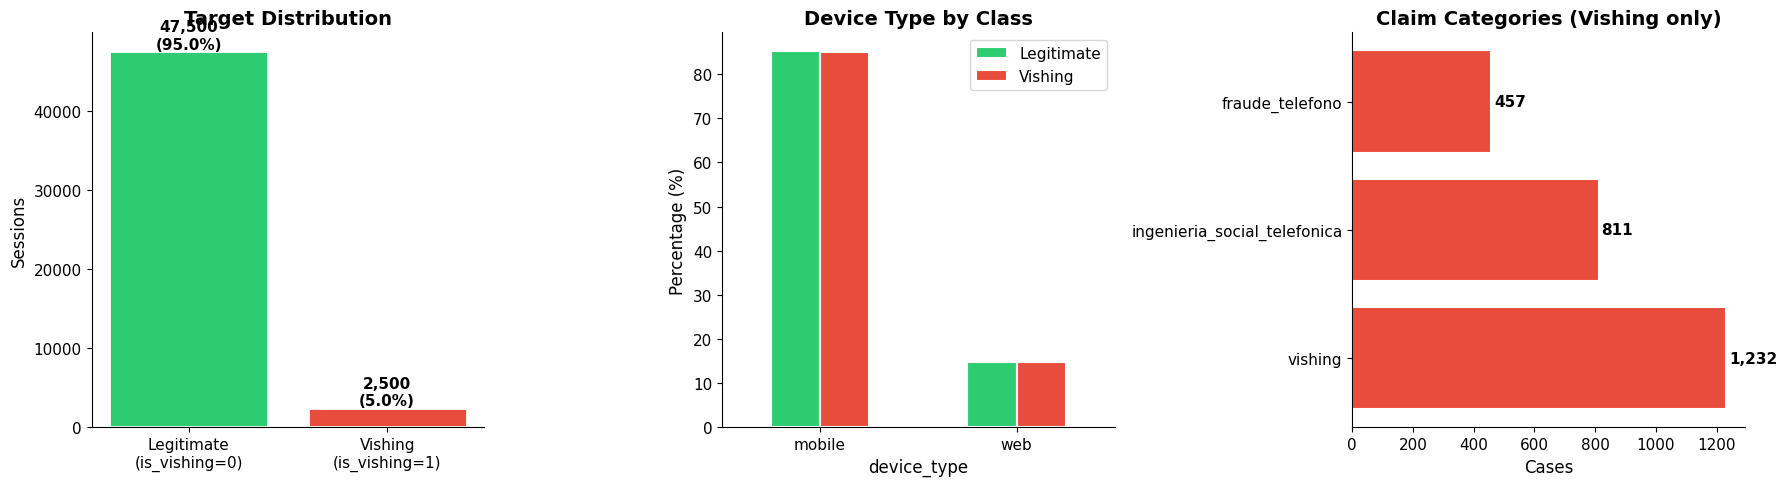

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1 Target distribution
counts = df['is_vishing'].value_counts()
bars = axes[0].bar(['Legitimate\n(is_vishing=0)', 'Vishing\n(is_vishing=1)'],
                    counts.values, color=[COLORS['legit'], COLORS['vishing']],
                    edgecolor='white', linewidth=2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].set_ylabel('Sessions')

# 3.2 Device type by label
ct = pd.crosstab(df['device_type'], df['is_vishing'], normalize='columns') * 100
ct.plot(kind='bar', ax=axes[1], color=[COLORS['legit'], COLORS['vishing']],
        edgecolor='white', linewidth=1.5)
axes[1].set_title('Device Type by Class', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Legitimate', 'Vishing'])

# 3.3 Claim category
claim_counts = df[df['is_vishing']==1]['claim_category'].value_counts()
axes[2].barh(claim_counts.index, claim_counts.values, color=COLORS['vishing'],
             edgecolor='white', linewidth=1.5)
for i, v in enumerate(claim_counts.values):
    axes[2].text(v + 10, i, f'{v:,}', va='center', fontweight='bold')
axes[2].set_title('Claim Categories (Vishing only)', fontweight='bold')
axes[2].set_xlabel('Cases')

plt.tight_layout()
plt.show()

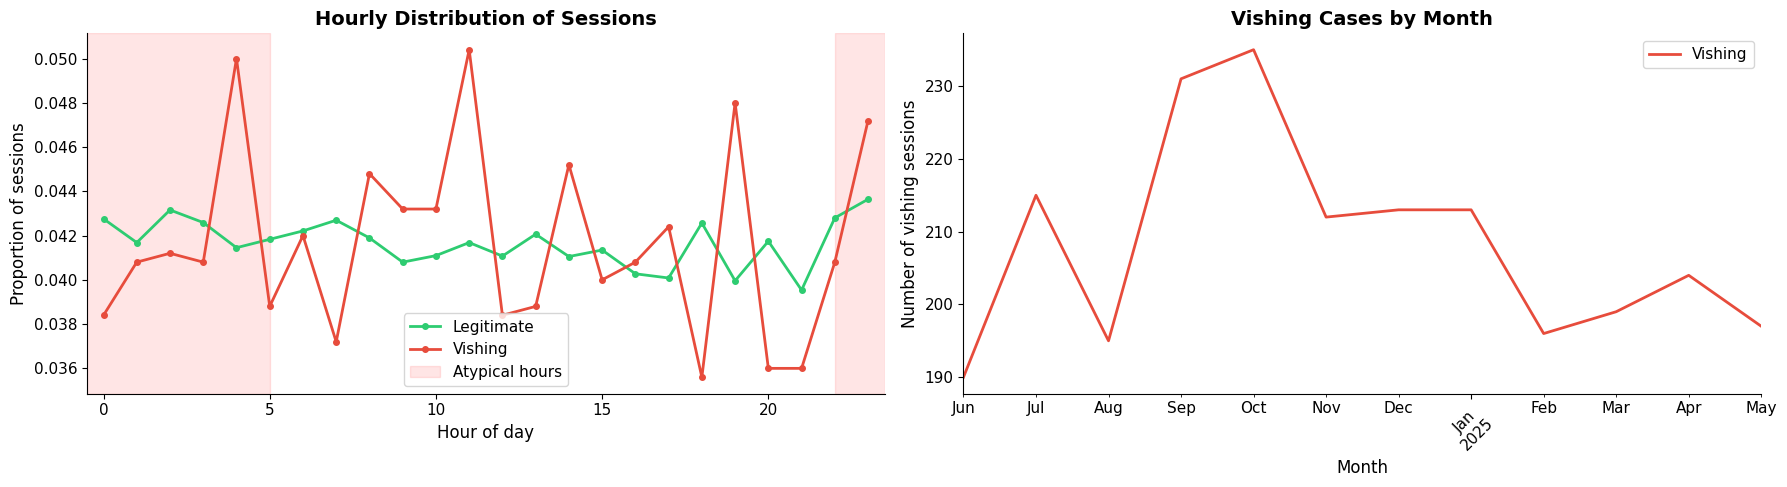

In [7]:
# 3.4 Temporal distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# By hour of day
for label, subset, color in [(0, df_legit, COLORS['legit']), (1, df_vishing, COLORS['vishing'])]:
    hour_dist = subset['hour_of_day'].value_counts().sort_index()
    hour_dist = hour_dist / hour_dist.sum()  # normalize
    axes[0].plot(hour_dist.index, hour_dist.values, '-o', color=color,
                 label=LABEL_MAP[label], linewidth=2, markersize=4)

axes[0].axvspan(22, 23.5, alpha=0.1, color='red', label='Atypical hours')
axes[0].axvspan(-0.5, 5, alpha=0.1, color='red')
axes[0].set_title('Hourly Distribution of Sessions', fontweight='bold')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Proportion of sessions')
axes[0].legend()
axes[0].set_xlim(-0.5, 23.5)

# By month
df['month'] = df['session_timestamp'].dt.to_period('M')
monthly = df.groupby(['month', 'is_vishing']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0)
monthly[1].plot(ax=axes[1], color=COLORS['vishing'], linewidth=2, label='Vishing')
axes[1].set_title('Vishing Cases by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of vishing sessions')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
df.drop(columns='month', inplace=True)

plt.tight_layout()
plt.show()

## 4. Univariate Analysis — Feature Distribution by Class

We compare the distribution of each feature between legitimate and vishing sessions. 
The differences in these distributions are the signal the model will need to learn.

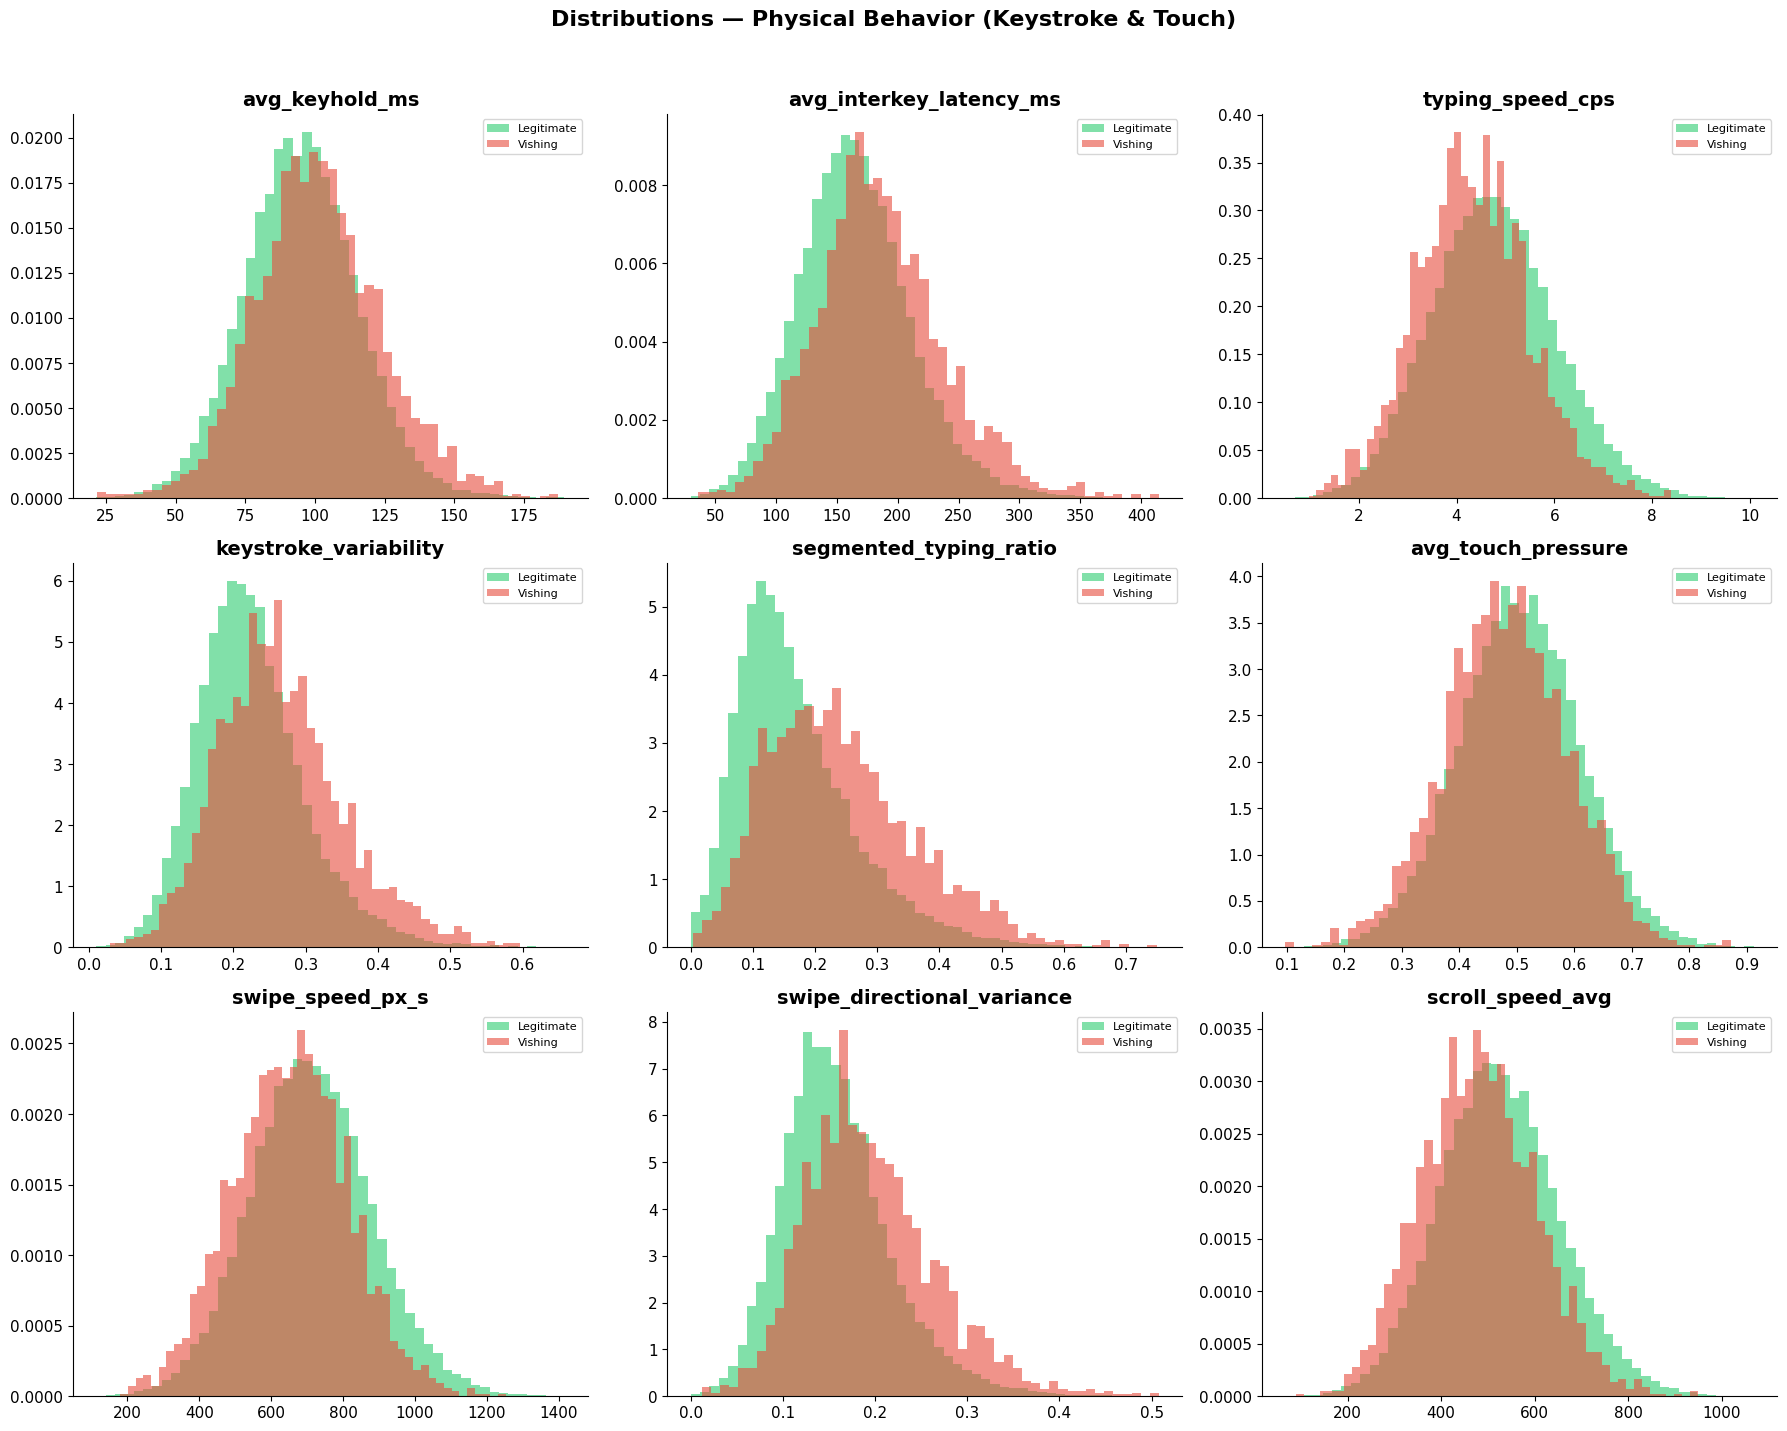

In [9]:
# 4.1 Key physical behavior features (keystroke + touch)
physical_features = [
    'avg_keyhold_ms', 'avg_interkey_latency_ms', 'typing_speed_cps',
    'keystroke_variability', 'segmented_typing_ratio', 'avg_touch_pressure',
    'swipe_speed_px_s', 'swipe_directional_variance', "scroll_speed_avg"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, feat in enumerate(physical_features):
    ax = axes[i]
    ax.hist(df_legit[feat], bins=50, alpha=0.6, color=COLORS['legit'],
            label='Legitimate', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=50, alpha=0.6, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distributions — Physical Behavior (Keystroke & Touch)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

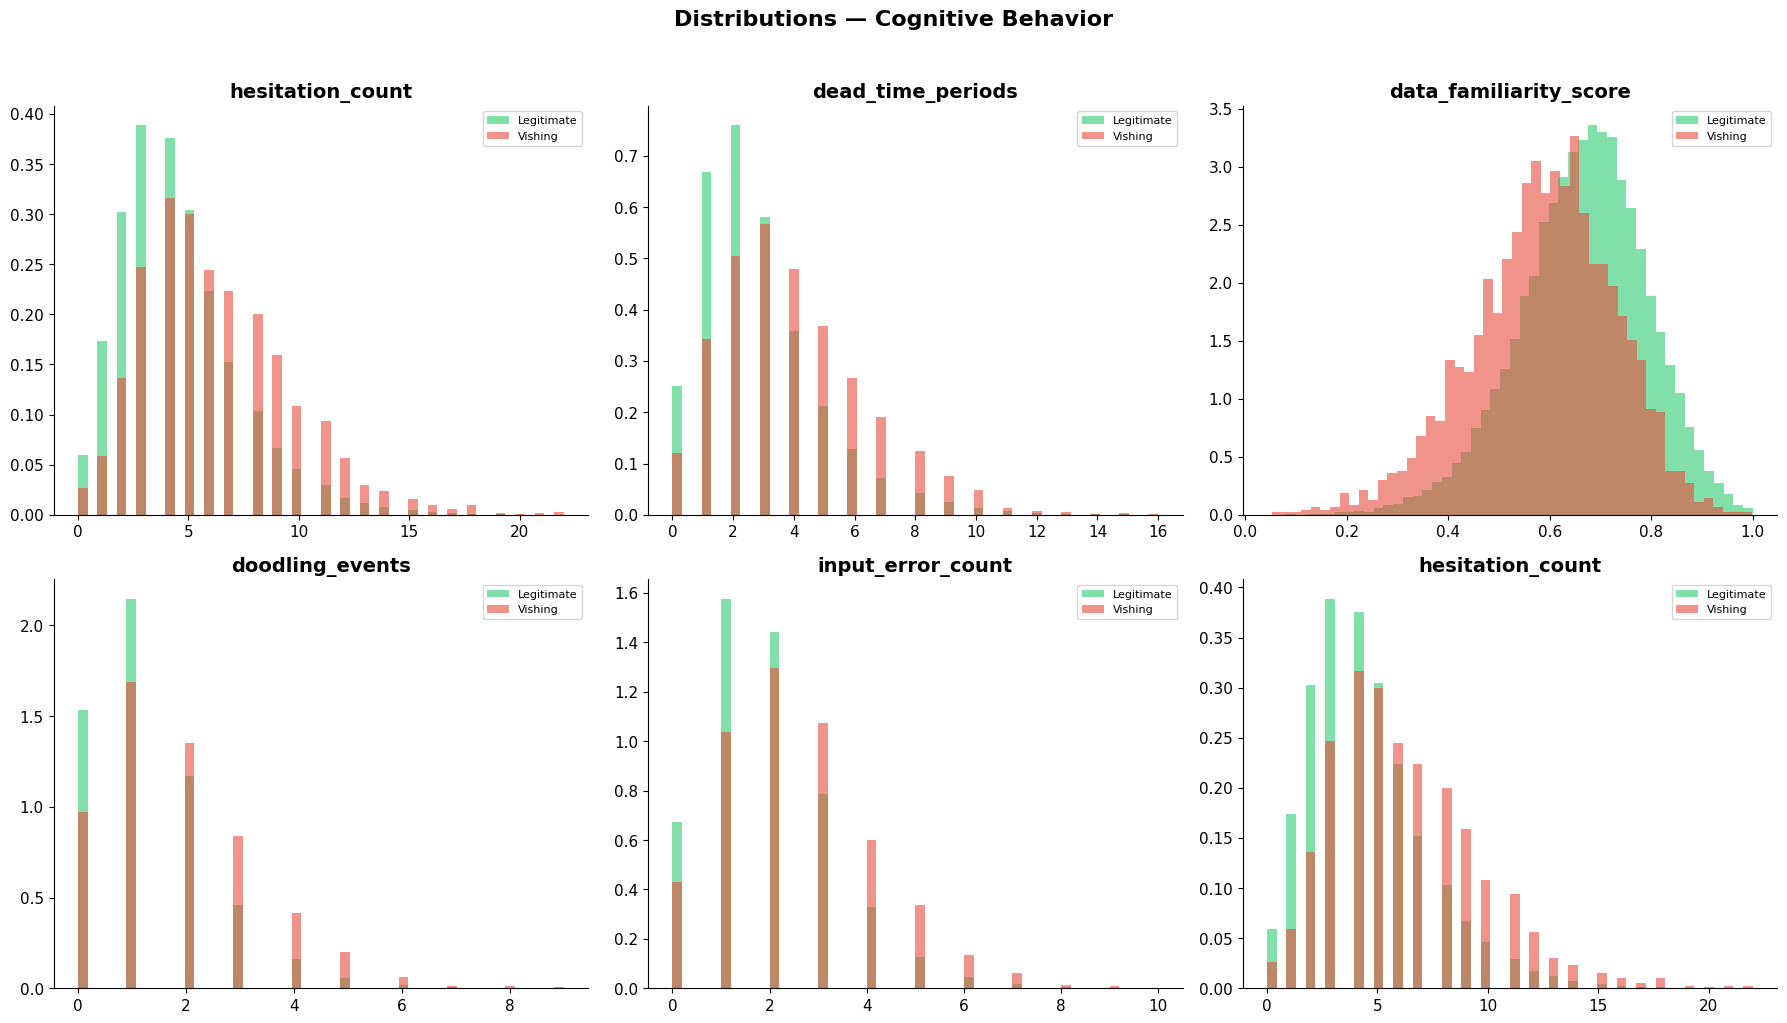

In [21]:
# 4.2 Key cognitive features
cognitive_features = [
    'hesitation_count', 'dead_time_periods', 'data_familiarity_score',
    'doodling_events', 'input_error_count', 'hesitation_count'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(cognitive_features):
    ax = axes[i]
    ax.hist(df_legit[feat], bins=50, alpha=0.6, color=COLORS['legit'],
            label='Legitimate', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=50, alpha=0.6, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distributions — Cognitive Behavior',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

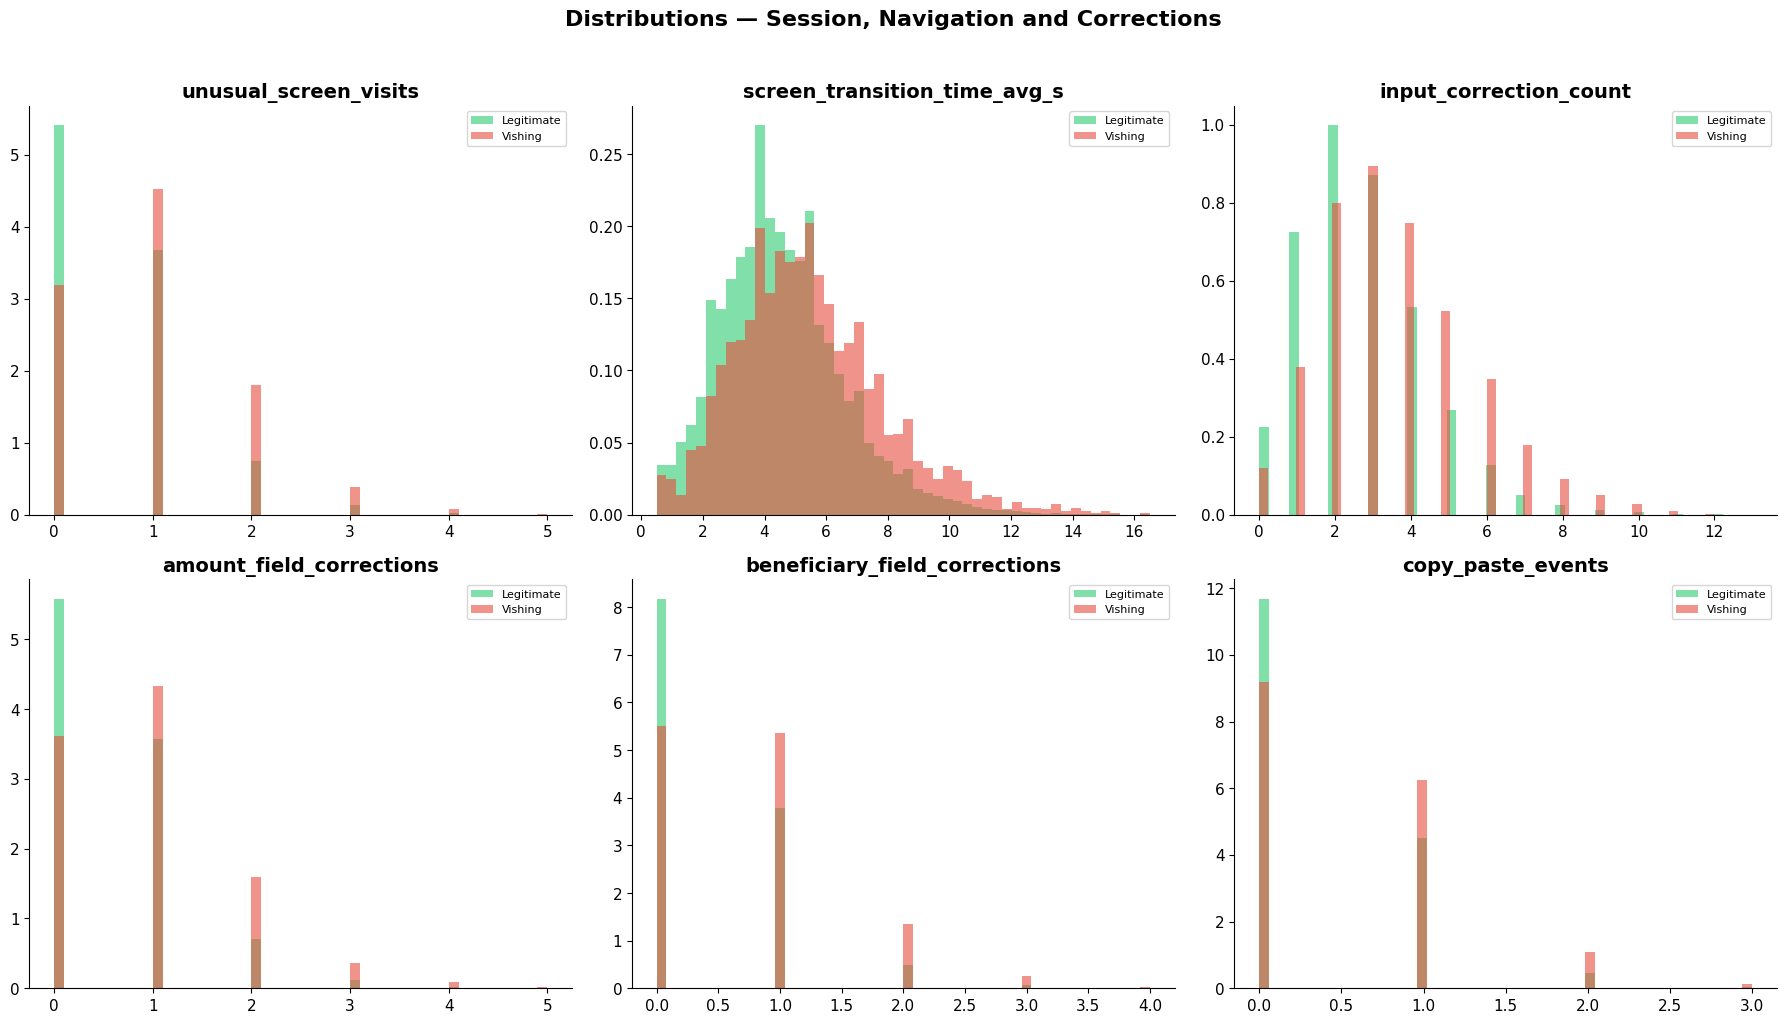

In [20]:
# 4.3 Session and context features
session_features = [
    'unusual_screen_visits',
    'screen_transition_time_avg_s',
    'input_correction_count', 'amount_field_corrections',
    'beneficiary_field_corrections', 'copy_paste_events'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(session_features):
    ax = axes[i]
    ax.hist(df_legit[feat], bins=50, alpha=0.6, color=COLORS['legit'],
            label='Legitimate', density=True, edgecolor='none')
    ax.hist(df_vishing[feat], bins=50, alpha=0.6, color=COLORS['vishing'],
            label='Vishing', density=True, edgecolor='none')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Distributions — Session, Navigation and Corrections',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Statistical Separability Tests

For each numeric feature we compute:
- **Mann-Whitney U test**: non-parametric test for distribution difference (does not assume normality)
- **Effect size (Cohen's d)**: practical magnitude of the difference
- **Point-biserial correlation**: correlation with the binary target
- **Univariate AUC**: individual discrimination capacity of each feature


In [22]:
from sklearn.metrics import roc_auc_score

# Features to evaluate (exclude IDs, timestamps, labels, BioCatch scores)
exclude = ['is_vishing', 'days_to_claim', 'biocatch_risk_score', 'biocatch_genuine_score',
           'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator']
features_to_test = [c for c in numeric_cols if c not in exclude]

results = []
for feat in features_to_test:
    x0 = df_legit[feat].dropna()
    x1 = df_vishing[feat].dropna()
    
    # Mann-Whitney U
    u_stat, p_val = mannwhitneyu(x0, x1, alternative='two-sided')
    
    # Cohen's d
    pooled_std = np.sqrt((x0.std()**2 + x1.std()**2) / 2)
    cohens_d = (x1.mean() - x0.mean()) / pooled_std if pooled_std > 0 else 0
    
    # Point-biserial correlation
    r_pb, p_pb = pointbiserialr(df['is_vishing'], df[feat])
    
    # Univariate AUC
    try:
        auc = roc_auc_score(df['is_vishing'], df[feat])
        auc = max(auc, 1 - auc)  # ensure > 0.5
    except:
        auc = 0.5
    
    results.append({
        'feature': feat,
        'mean_legit': x0.mean(),
        'mean_vishing': x1.mean(),
        'pct_change': ((x1.mean() - x0.mean()) / x0.mean() * 100) if x0.mean() != 0 else np.inf,
        'cohens_d': cohens_d,
        'abs_cohens_d': abs(cohens_d),
        'mann_whitney_p': p_val,
        'point_biserial_r': r_pb,
        'auc_univariate': auc,
    })

df_stats = pd.DataFrame(results).sort_values('abs_cohens_d', ascending=False)

# Classify effect size
def classify_effect(d):
    d = abs(d)
    if d >= 1.2: return '🔴 Very large'
    elif d >= 0.8: return '🟠 Large'
    elif d >= 0.5: return '🟡 Medium'
    elif d >= 0.2: return '🔵 Small'
    else: return '⚪ Negligible'

df_stats['effect_size'] = df_stats['cohens_d'].apply(classify_effect)
df_stats['significant'] = df_stats['mann_whitney_p'] < 0.001

print(f'Features evaluated: {len(df_stats)}')
print(f'\nEffect size distribution:')
print(df_stats['effect_size'].value_counts().to_string())
print(f'\nSignificant (p < 0.001): {df_stats["significant"].sum()} of {len(df_stats)}')

Features evaluated: 47

Effect size distribution:
effect_size
🔵 Small         23
⚪ Negligible    16
🟡 Medium         8

Significant (p < 0.001): 38 of 47


In [23]:
# Full results table — Top 30 features by |Cohen's d|
display_cols = ['feature', 'mean_legit', 'mean_vishing', 'pct_change',
                'cohens_d', 'effect_size', 'auc_univariate', 'point_biserial_r']

styled = (df_stats[display_cols].head(30)
          .style
          .format({
              'mean_legit': '{:.3f}',
              'mean_vishing': '{:.3f}',
              'pct_change': '{:+.1f}%',
              'cohens_d': '{:+.3f}',
              'auc_univariate': '{:.4f}',
              'point_biserial_r': '{:+.4f}',
          })
          .bar(subset=['auc_univariate'], color='#3498db', vmin=0.5, vmax=1.0)
)
styled

,feature,mean_legit,mean_vishing,pct_change,cohens_d,effect_size,auc_univariate,point_biserial_r
4,segmented_typing_ratio,0.169,0.241,+42.2%,+0.667,🟡 Medium,0.6890,+0.1585
31,data_familiarity_score,0.665,0.588,-11.7%,-0.586,🟡 Medium,0.6609,-0.1333
15,hesitation_count,4.500,6.260,+39.1%,+0.574,🟡 Medium,0.6614,+0.1372
8,swipe_directional_variance,0.159,0.195,+22.6%,+0.547,🟡 Medium,0.6540,+0.1285
18,dead_time_periods,2.739,3.948,+44.1%,+0.537,🟡 Medium,0.6533,+0.1274
27,input_correction_count,2.691,3.642,+35.3%,+0.515,🟡 Medium,0.6422,+0.1213
3,keystroke_variability,0.225,0.266,+18.4%,+0.510,🟡 Medium,0.6450,+0.1187
23,unusual_screen_visits,0.567,0.965,+70.1%,+0.505,🟡 Medium,0.6325,+0.1200
29,beneficiary_field_corrections,0.396,0.714,+80.6%,+0.469,🔵 Small,0.6168,+0.1148
14,phone_motion_events,12.697,15.602,+22.9%,+0.468,🔵 Small,0.6299,+0.1111


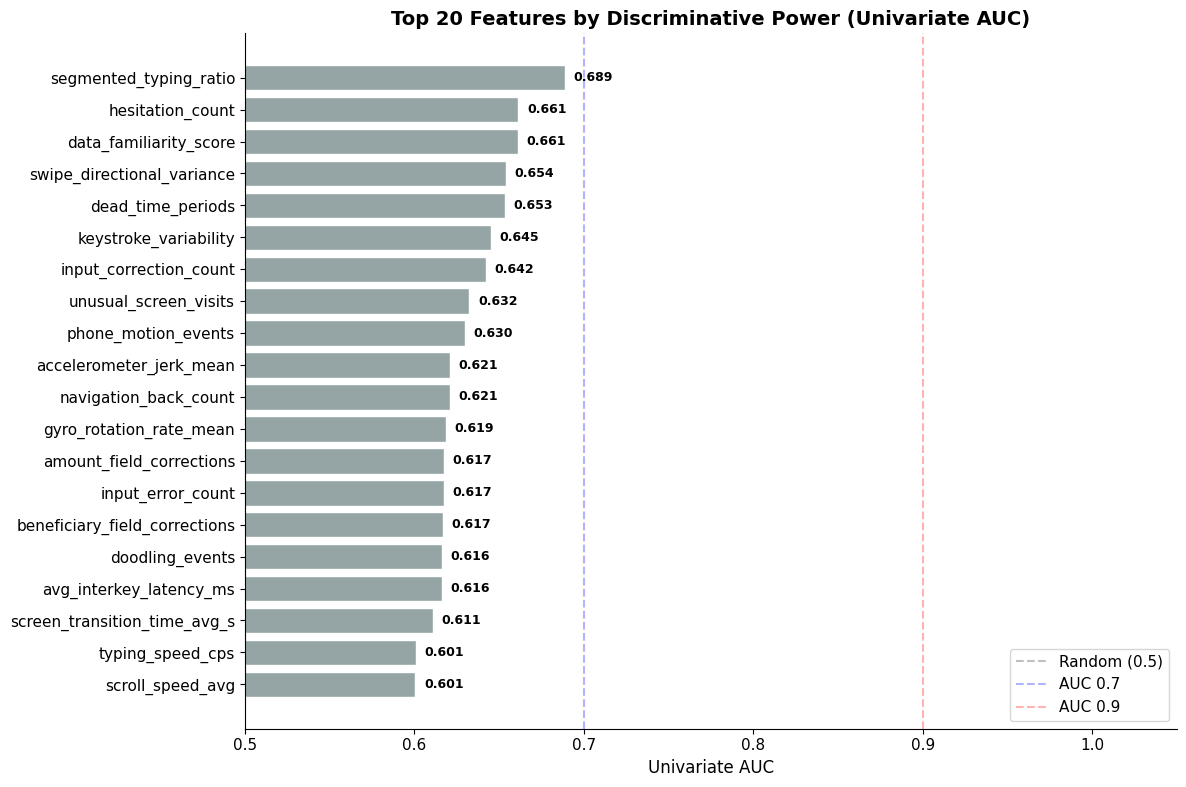

In [24]:
# 5.2 Visualization: Top 20 features by univariate AUC
top20 = df_stats.nlargest(20, 'auc_univariate')

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if x >= 0.9 else '#f39c12' if x >= 0.8 else '#3498db' if x >= 0.7 else '#95a5a6'
          for x in top20['auc_univariate']]

bars = ax.barh(range(len(top20)), top20['auc_univariate'].values, color=colors,
               edgecolor='white', linewidth=1)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values)
ax.set_xlabel('Univariate AUC')
ax.set_title('Top 20 Features by Discriminative Power (Univariate AUC)', fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.axvline(x=0.7, color='blue', linestyle='--', alpha=0.3, label='AUC 0.7')
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.3, label='AUC 0.9')

for bar, val in zip(bars, top20['auc_univariate'].values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9, fontweight='bold')

ax.legend(loc='lower right')
ax.set_xlim(0.5, 1.05)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

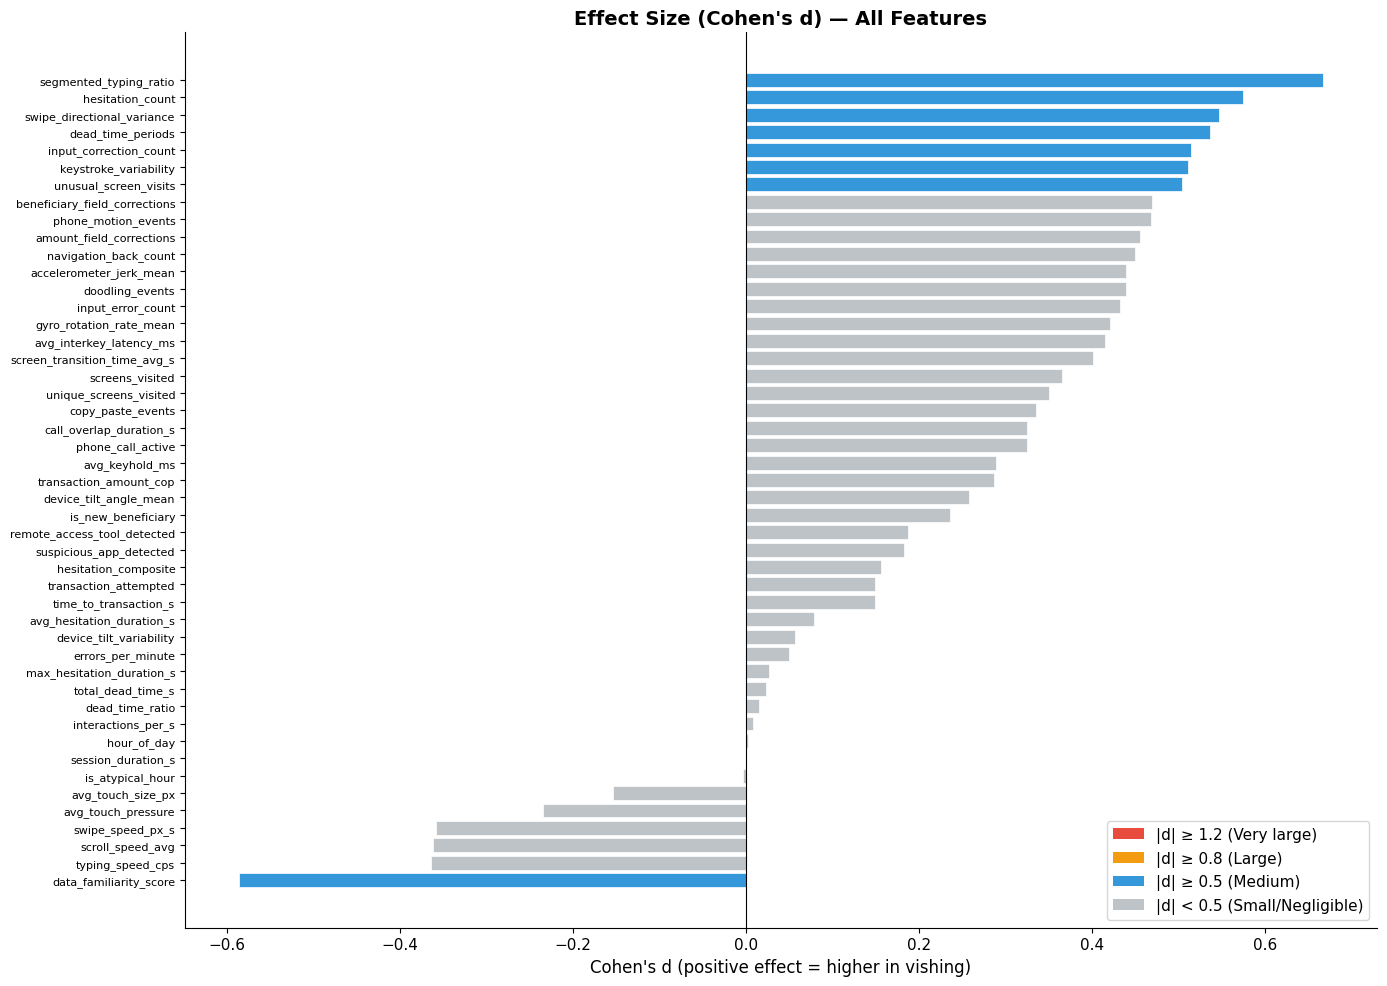

In [25]:
# 5.3 Cohen's d — all features
fig, ax = plt.subplots(figsize=(14, 10))

df_sorted = df_stats.sort_values('cohens_d')
colors_d = ['#e74c3c' if abs(d) >= 1.2 else '#f39c12' if abs(d) >= 0.8 
            else '#3498db' if abs(d) >= 0.5 else '#bdc3c7' for d in df_sorted['cohens_d']]

ax.barh(range(len(df_sorted)), df_sorted['cohens_d'].values, color=colors_d,
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['feature'].values, fontsize=8)
ax.set_xlabel("Cohen's d (positive effect = higher in vishing)")
ax.set_title("Effect Size (Cohen's d) — All Features", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Manual legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='|d| ≥ 1.2 (Very large)'),
    Patch(facecolor='#f39c12', label='|d| ≥ 0.8 (Large)'),
    Patch(facecolor='#3498db', label='|d| ≥ 0.5 (Medium)'),
    Patch(facecolor='#bdc3c7', label='|d| < 0.5 (Small/Negligible)'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 6. Analysis of Binary and Categorical Variables

For the binary variables (phone_call_active, is_new_beneficiary, etc.) 
we use chi-square and odds ratio.

In [26]:
binary_features = ['phone_call_active', 'is_atypical_hour', 'transaction_attempted',
                   'is_new_beneficiary', 'remote_access_tool_detected', 'suspicious_app_detected']

binary_results = []
for feat in binary_features:
    ct = pd.crosstab(df[feat], df['is_vishing'])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # Odds ratio
    a, b = ct.iloc[1, 1], ct.iloc[1, 0]  # vishing=1 & feat=1, legit & feat=1
    c, d_ = ct.iloc[0, 1], ct.iloc[0, 0]  # vishing=1 & feat=0, legit & feat=0
    odds_ratio = (a * d_) / (b * c) if (b * c) > 0 else np.inf
    
    pct_legit = df_legit[feat].mean() * 100
    pct_vishing = df_vishing[feat].mean() * 100
    
    binary_results.append({
        'feature': feat,
        'pct_legit': pct_legit,
        'pct_vishing': pct_vishing,
        'chi2': chi2,
        'p_value': p,
        'odds_ratio': odds_ratio,
    })

df_binary = pd.DataFrame(binary_results).sort_values('odds_ratio', ascending=False)

print('BINARY VARIABLE ANALYSIS (Chi-square + Odds Ratio)')
print('='*80)
for _, row in df_binary.iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else 'ns'
    print(f"\n  {row['feature']}:")
    print(f"    Legitimate: {row['pct_legit']:.1f}%  |  Vishing: {row['pct_vishing']:.1f}%")
    print(f"    Odds Ratio: {row['odds_ratio']:.2f}x  |  χ²={row['chi2']:.1f}  |  {sig}")

BINARY VARIABLE ANALYSIS (Chi-square + Odds Ratio)

  remote_access_tool_detected:
    Legitimate: 2.7%  |  Vishing: 6.6%
    Odds Ratio: 2.57x  |  χ²=130.2  |  ***

  suspicious_app_detected:
    Legitimate: 5.1%  |  Vishing: 9.9%
    Odds Ratio: 2.05x  |  χ²=107.3  |  ***

  phone_call_active:
    Legitimate: 24.4%  |  Vishing: 39.3%
    Odds Ratio: 2.01x  |  χ²=281.9  |  ***

  is_new_beneficiary:
    Legitimate: 17.7%  |  Vishing: 27.4%
    Odds Ratio: 1.76x  |  χ²=152.5  |  ***

  transaction_attempted:
    Legitimate: 55.6%  |  Vishing: 62.9%
    Odds Ratio: 1.35x  |  χ²=51.2  |  ***

  is_atypical_hour:
    Legitimate: 34.0%  |  Vishing: 33.8%
    Odds Ratio: 0.99x  |  χ²=0.0  |  ns


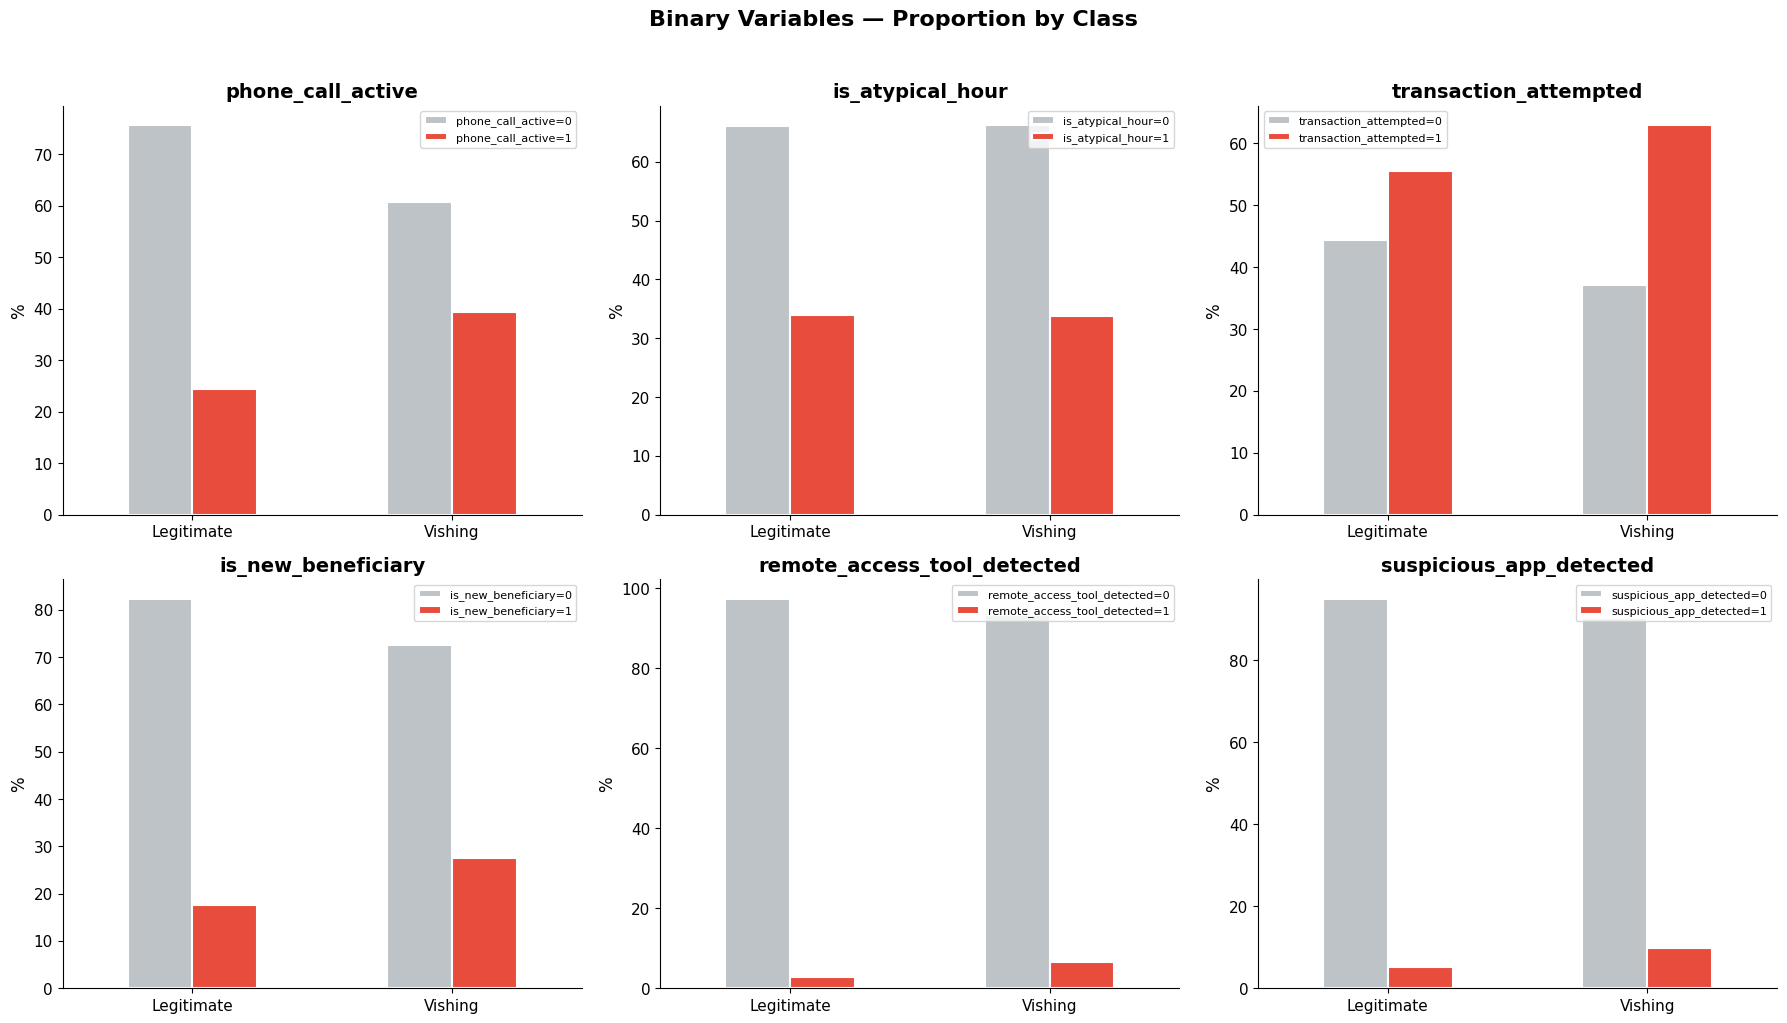

In [27]:
# Visualization of binary variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(binary_features):
    ax = axes[i]
    ct = pd.crosstab(df['is_vishing'], df[feat], normalize='index') * 100
    ct.index = ['Legitimate', 'Vishing']
    ct.columns = [f'{feat}=0', f'{feat}=1']
    ct.plot(kind='bar', ax=ax, color=['#bdc3c7', COLORS['vishing']],
            edgecolor='white', linewidth=1.5)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('Binary Variables — Proportion by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Comparative Boxplots — Top Features

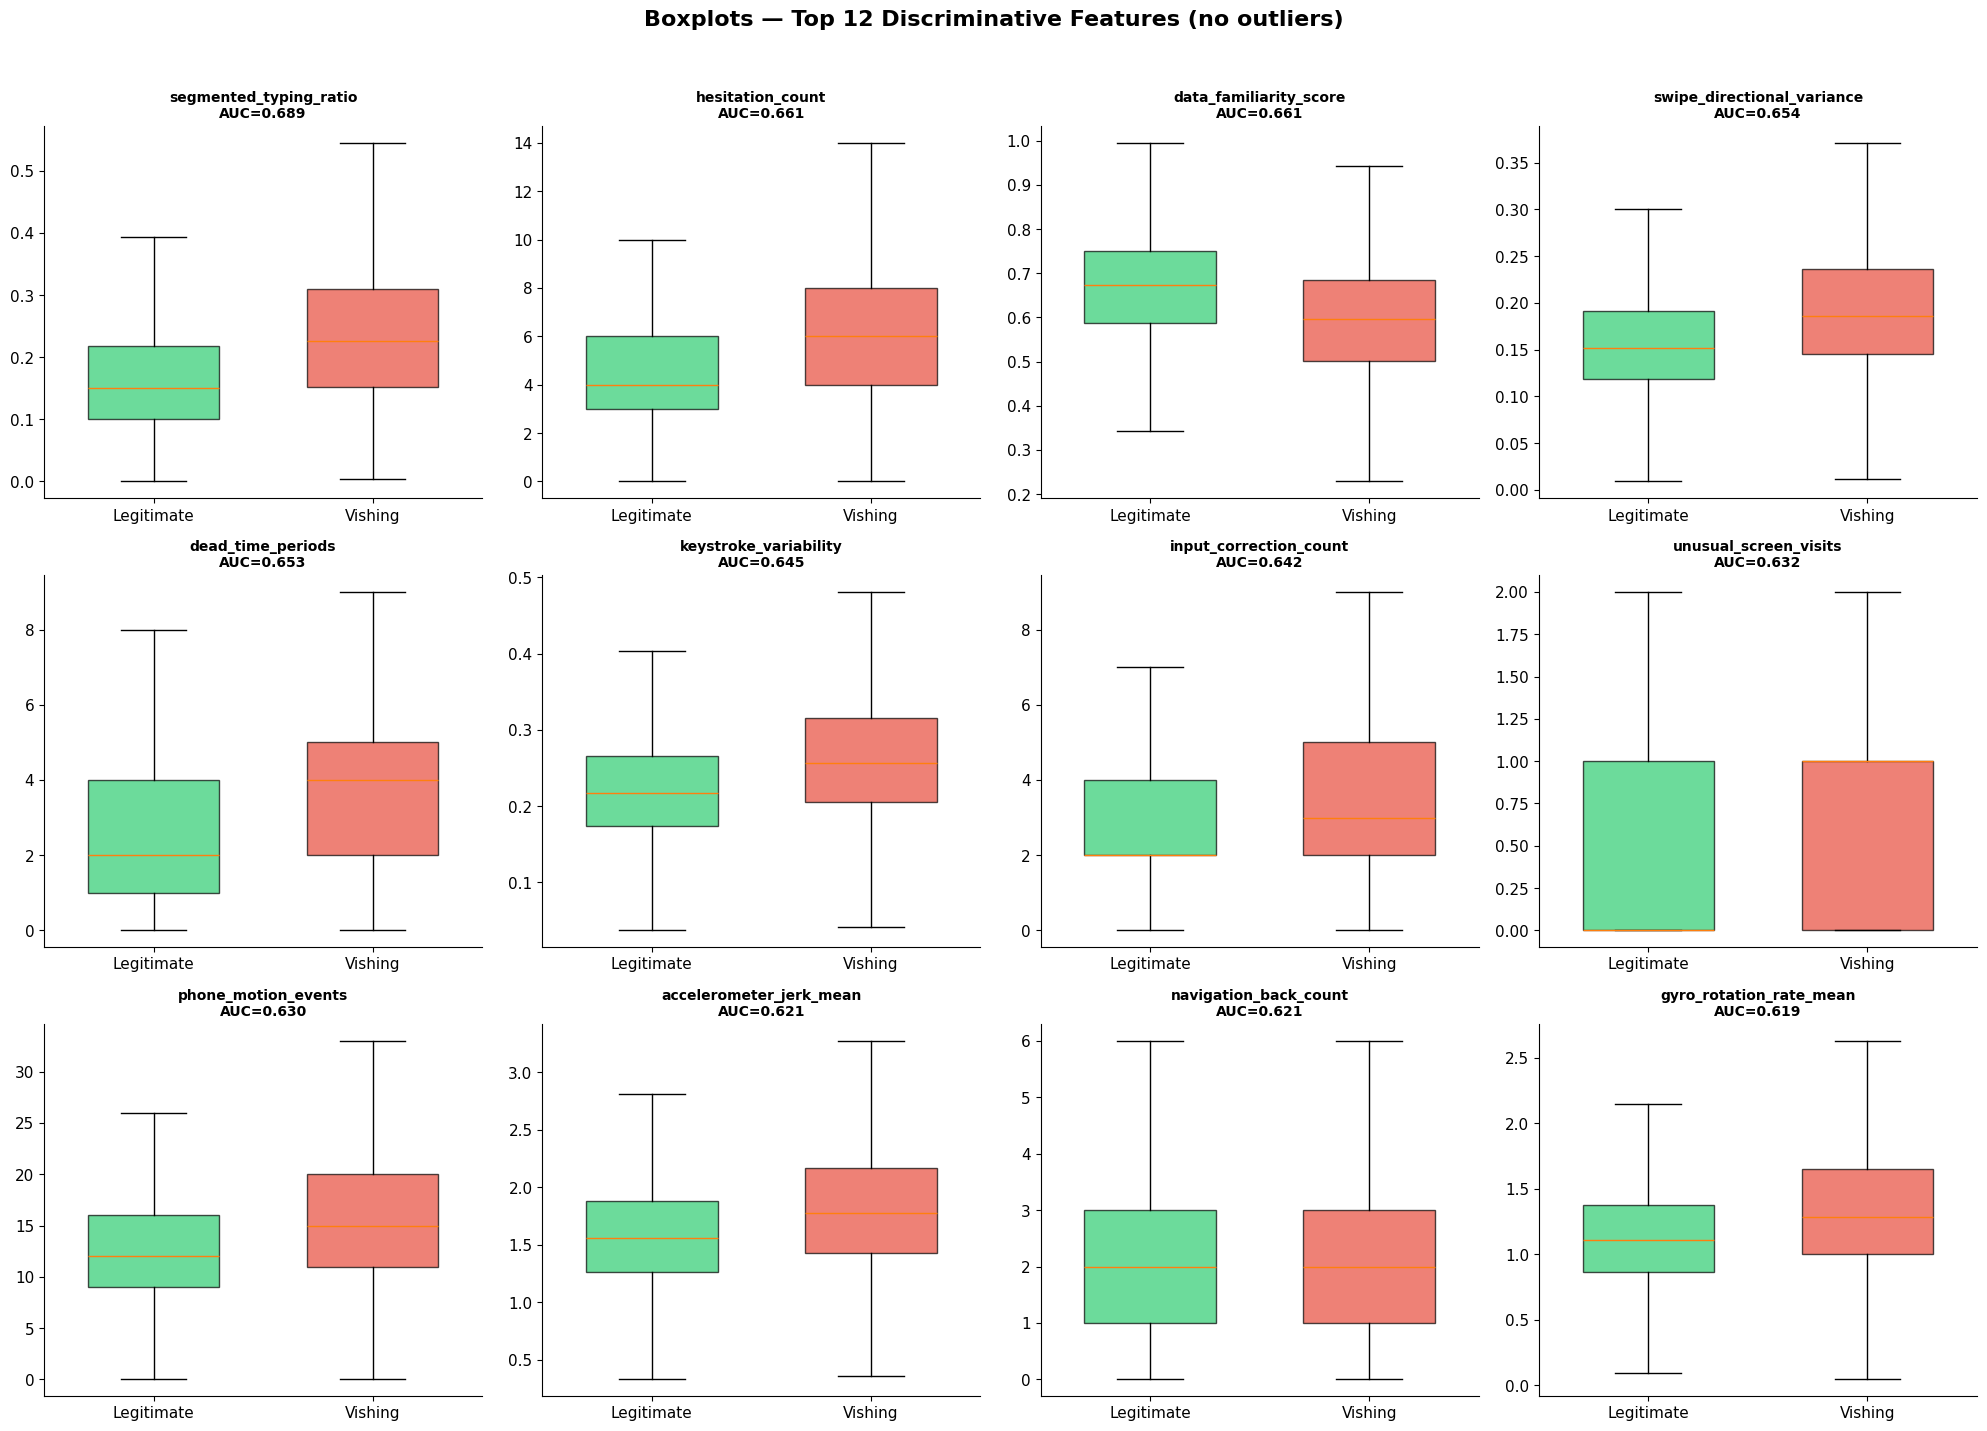

In [28]:
# Top 12 features by AUC
top12 = df_stats.nlargest(12, 'auc_univariate')['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.ravel()

for i, feat in enumerate(top12):
    ax = axes[i]
    data_to_plot = [df_legit[feat].values, df_vishing[feat].values]
    bp = ax.boxplot(data_to_plot, labels=['Legitimate', 'Vishing'], patch_artist=True,
                    widths=0.6, showfliers=False)
    bp['boxes'][0].set_facecolor(COLORS['legit'])
    bp['boxes'][1].set_facecolor(COLORS['vishing'])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    
    auc_val = df_stats[df_stats['feature']==feat]['auc_univariate'].values[0]
    ax.set_title(f'{feat}\nAUC={auc_val:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Boxplots — Top 12 Discriminative Features (no outliers)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

We examine correlations between features to identify redundancies and variable clusters.

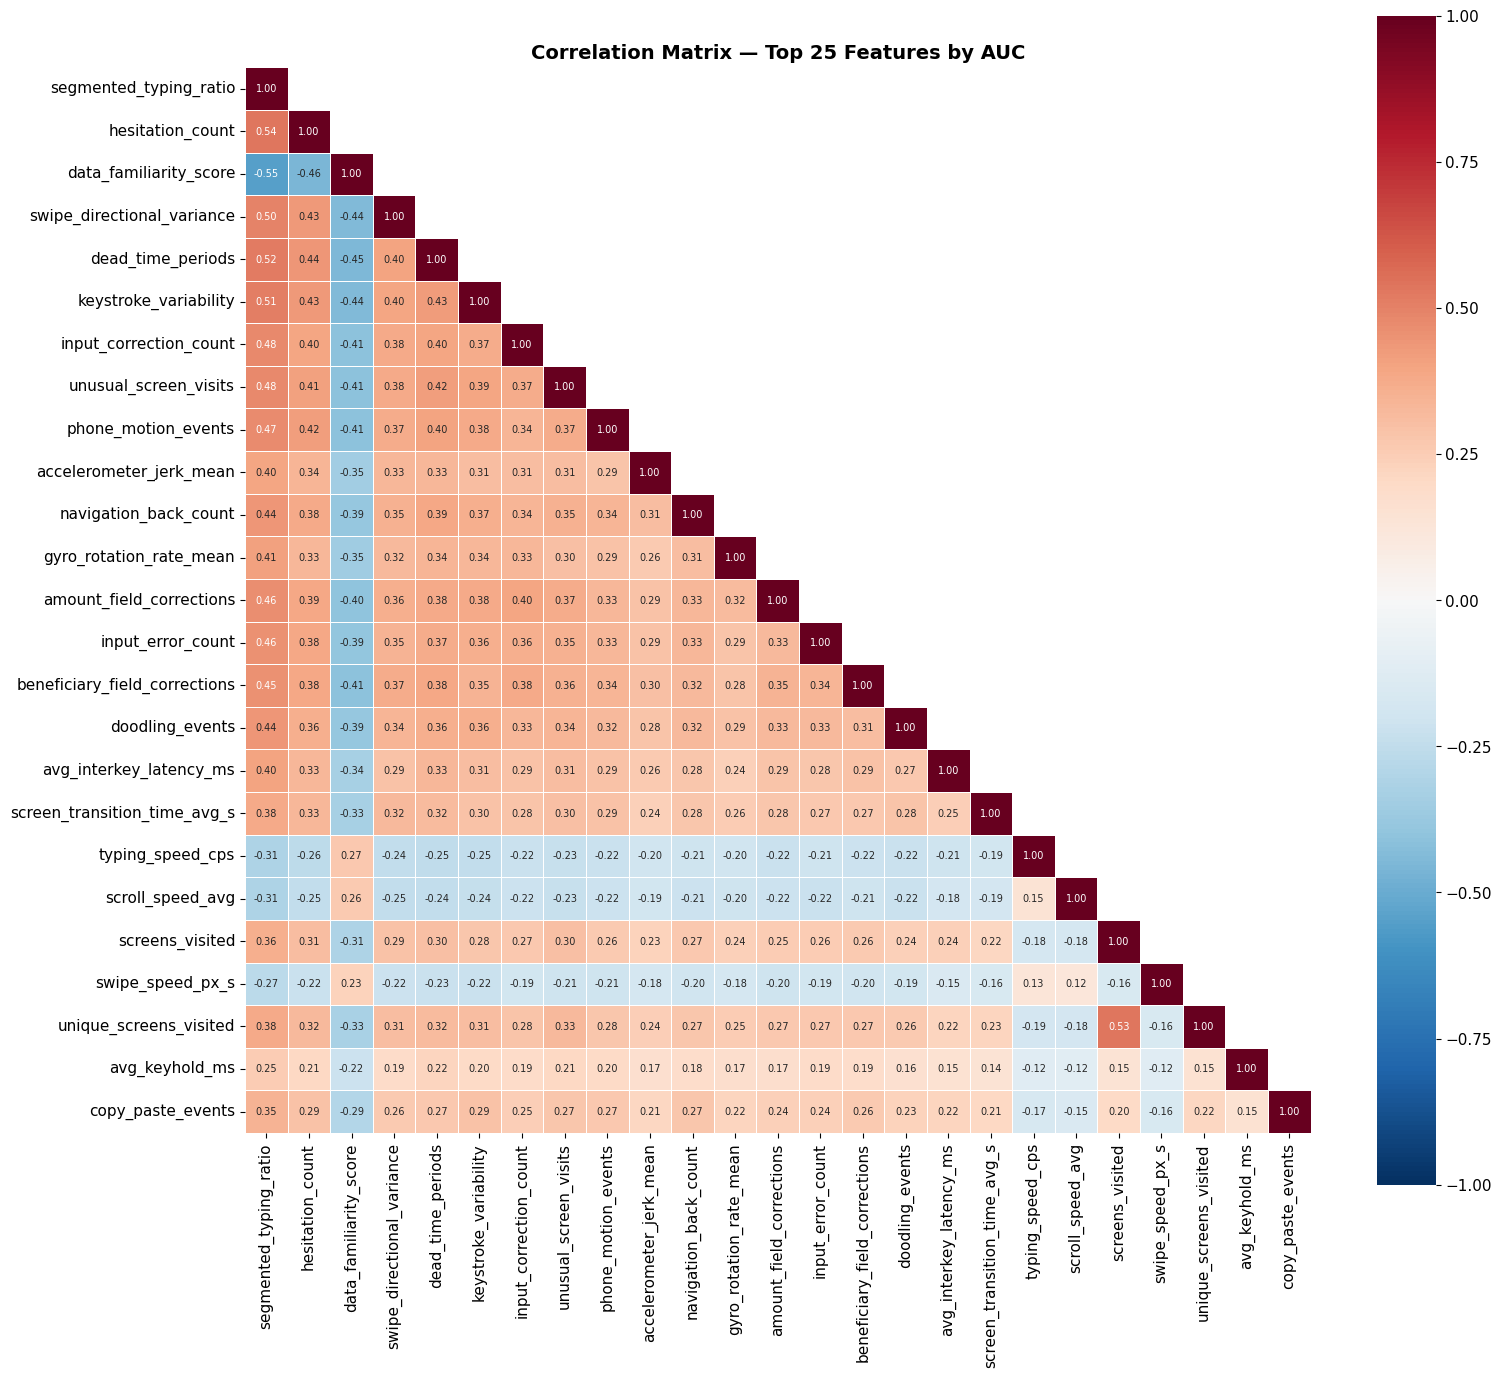

In [29]:
# 8.1 Correlation matrix of the top 25 features
top25_feats = df_stats.nlargest(25, 'auc_univariate')['feature'].tolist()
corr_matrix = df[top25_feats].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7}, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Top 25 Features by AUC', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
# 8.2 Identify highly correlated pairs (|r| > 0.7)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': r
            })

# empty case
df_high_corr = pd.DataFrame(high_corr, columns=['feature_1', 'feature_2', 'correlation'])

if not df_high_corr.empty:
    df_high_corr = df_high_corr.sort_values('correlation', key=abs, ascending=False)

print(f'Pairs with |correlation| > 0.7: {len(df_high_corr)}')
print()
if not df_high_corr.empty:
    for _, row in df_high_corr.iterrows():
        print(f"  {row['feature_1']:35s} ↔ {row['feature_2']:35s}  r={row['correlation']:+.3f}")
    print('\n⚠️  Consider removing one of each pair or using PCA to avoid multicollinearity.')
else:
    print('  ✅ No pairs found with correlation > 0.7')

Pairs with |correlation| > 0.7: 0

  ✅ No pairs found with correlation > 0.7


## 9. Behavioral Profile of a Vishing Session

We build the comparative statistical profile: what does a vishing session look like 
compared to a legitimate session on average?

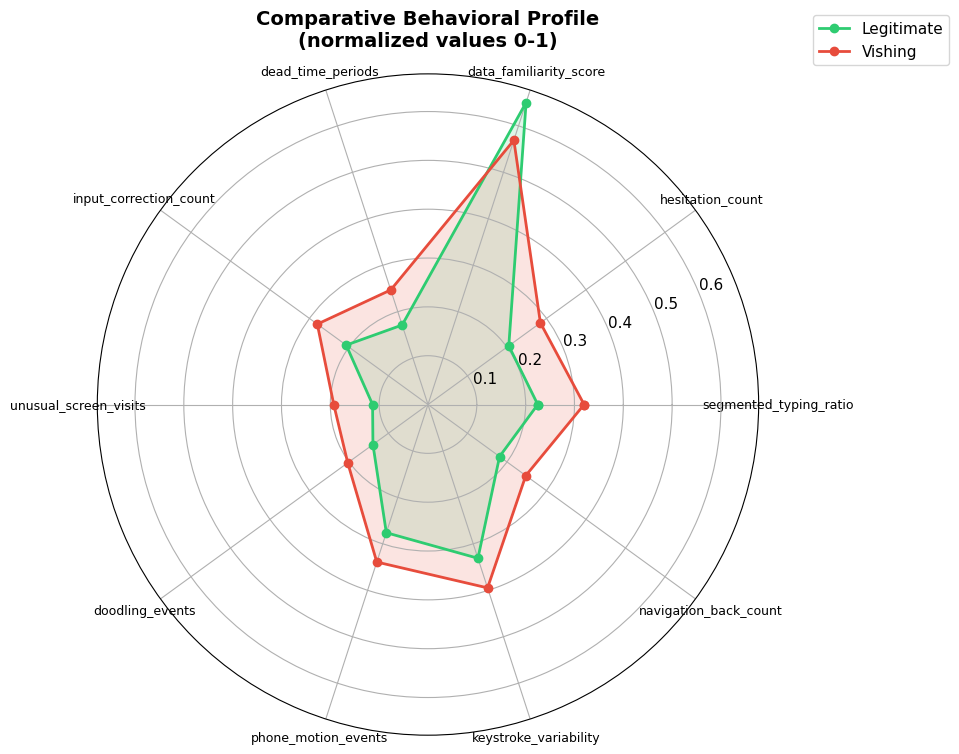

In [37]:
# Radar chart / comparative profile
profile_features = [
    'segmented_typing_ratio', 'hesitation_count', 'data_familiarity_score',
    'dead_time_periods', 'input_correction_count', 'unusual_screen_visits',
    'doodling_events', 'phone_motion_events', 'keystroke_variability',
    'navigation_back_count'
]

# Normalize to 0-1 for visual comparison
profile_data = []
for feat in profile_features:
    global_min = df[feat].min()
    global_max = df[feat].max()
    rng = global_max - global_min if global_max > global_min else 1
    legit_norm = (df_legit[feat].mean() - global_min) / rng
    vishing_norm = (df_vishing[feat].mean() - global_min) / rng
    profile_data.append({'feature': feat, 'legit': legit_norm, 'vishing': vishing_norm})

df_profile = pd.DataFrame(profile_data)

# Radar chart
angles = np.linspace(0, 2 * np.pi, len(profile_features), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

legit_vals = df_profile['legit'].tolist() + [df_profile['legit'].iloc[0]]
vishing_vals = df_profile['vishing'].tolist() + [df_profile['vishing'].iloc[0]]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.plot(angles, legit_vals, 'o-', color=COLORS['legit'], linewidth=2, label='Legitimate', markersize=6)
ax.fill(angles, legit_vals, alpha=0.15, color=COLORS['legit'])
ax.plot(angles, vishing_vals, 'o-', color=COLORS['vishing'], linewidth=2, label='Vishing', markersize=6)
ax.fill(angles, vishing_vals, alpha=0.15, color=COLORS['vishing'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(profile_features, fontsize=9)
ax.set_title('Comparative Behavioral Profile\n(normalized values 0-1)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

In [38]:
# Profile summary table
print('COMPARATIVE PROFILE — MEDIAN BY CLASS')
print('='*90)
print(f'{"Feature":40s} {"Legitimate":>12s} {"Vishing":>12s} {"Ratio":>10s} {"Direction":>12s}')
print('-'*90)

key_features = [
    'phone_call_active', 'segmented_typing_ratio', 'session_duration_s',
    'hesitation_count', 'avg_hesitation_duration_s', 'total_dead_time_s',
    'data_familiarity_score', 'typing_speed_cps', 'input_correction_count',
    'unusual_screen_visits', 'transaction_amount_cop', 'is_new_beneficiary',
    'doodling_events', 'phone_motion_events', 'keystroke_variability',
    'navigation_back_count', 'amount_field_corrections', 'beneficiary_field_corrections',
]

for feat in key_features:
    med_l = df_legit[feat].median()
    med_v = df_vishing[feat].median()
    ratio = med_v / med_l if med_l != 0 else float('inf')
    direction = '↑ HIGHER' if med_v > med_l else '↓ LOWER' if med_v < med_l else '= EQUAL'
    print(f'{feat:40s} {med_l:12.2f} {med_v:12.2f} {ratio:10.2f}x {direction:>12s}')

COMPARATIVE PROFILE — MEDIAN BY CLASS
Feature                                    Legitimate      Vishing      Ratio    Direction
------------------------------------------------------------------------------------------
phone_call_active                                0.00         0.00        infx      = EQUAL
segmented_typing_ratio                           0.15         0.23       1.51x     ↑ HIGHER
session_duration_s                               1.00         1.00       1.00x      = EQUAL
hesitation_count                                 4.00         6.00       1.50x     ↑ HIGHER
avg_hesitation_duration_s                        1.00         1.00       1.00x      = EQUAL
total_dead_time_s                                0.80         0.80       1.00x      = EQUAL
data_familiarity_score                           0.67         0.60       0.89x      ↓ LOWER
typing_speed_cps                                 4.73         4.30       0.91x      ↓ LOWER
input_correction_count                      

## 10. Transaction Analysis

Sessions with a transaction: 27,989
  Legitimate: 26,416 (55.6% of all legitimate)
  Vishing:    1,573 (62.9% of all vishing)


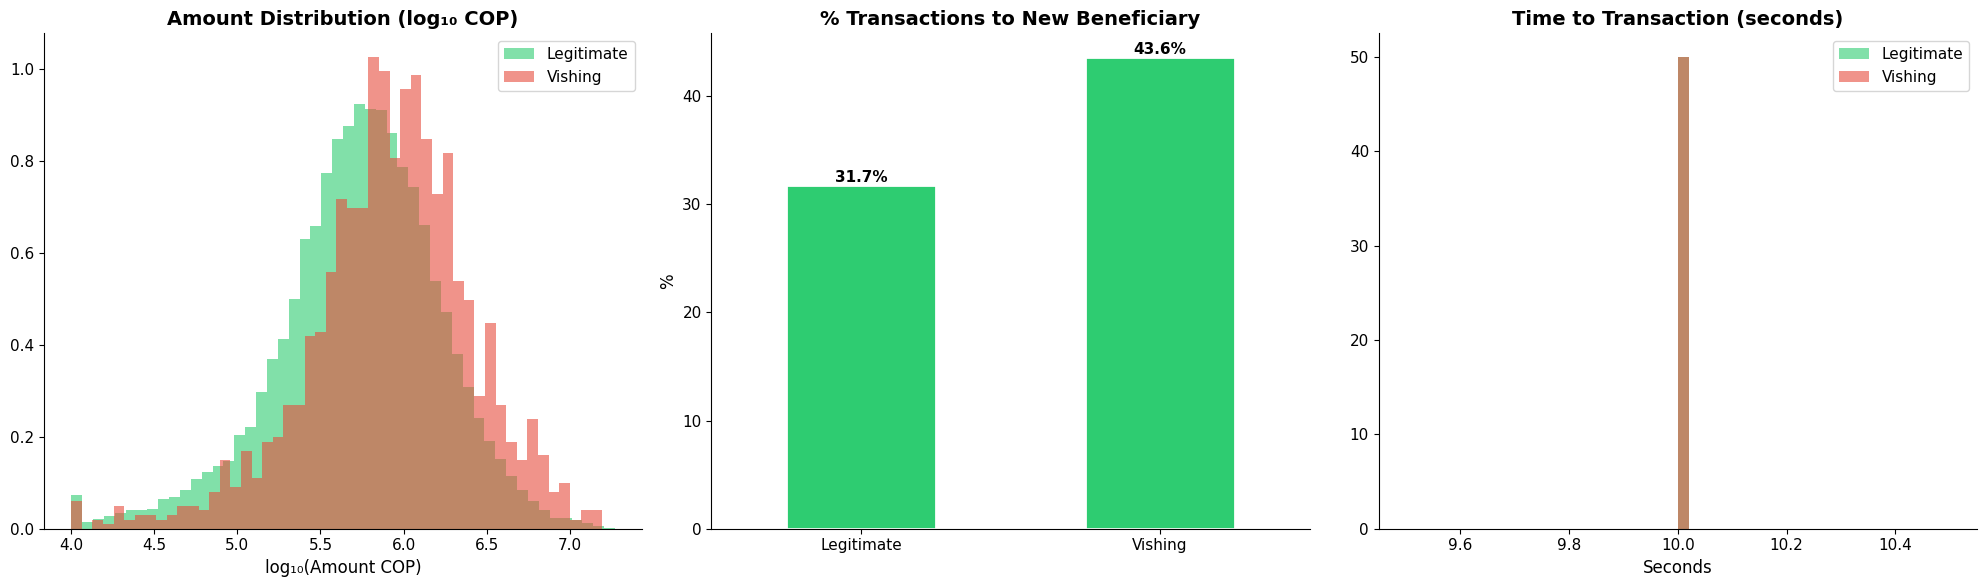

In [39]:
# Filter only sessions with a transaction
df_tx = df[df['transaction_attempted'] == 1].copy()
df_tx_legit = df_tx[df_tx['is_vishing'] == 0]
df_tx_vishing = df_tx[df_tx['is_vishing'] == 1]

print(f'Sessions with a transaction: {len(df_tx):,}')
print(f'  Legitimate: {len(df_tx_legit):,} ({len(df_tx_legit)/len(df_legit)*100:.1f}% of all legitimate)')
print(f'  Vishing:    {len(df_tx_vishing):,} ({len(df_tx_vishing)/len(df_vishing)*100:.1f}% of all vishing)')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Amount distribution (log scale)
for subset, color, label in [(df_tx_legit, COLORS['legit'], 'Legitimate'),
                              (df_tx_vishing, COLORS['vishing'], 'Vishing')]:
    amounts = subset['transaction_amount_cop']
    amounts = amounts[amounts > 0]
    axes[0].hist(np.log10(amounts), bins=50, alpha=0.6, color=color,
                 label=label, density=True, edgecolor='none')

axes[0].set_title('Amount Distribution (log₁₀ COP)', fontweight='bold')
axes[0].set_xlabel('log₁₀(Amount COP)')
axes[0].legend()

# New beneficiary
new_ben_rates = pd.DataFrame({
    'Legitimate': [df_tx_legit['is_new_beneficiary'].mean() * 100],
    'Vishing': [df_tx_vishing['is_new_beneficiary'].mean() * 100],
}).T
new_ben_rates.columns = ['% New beneficiary']
new_ben_rates.plot(kind='bar', ax=axes[1], color=[COLORS['legit'], COLORS['vishing']],
                   edgecolor='white', linewidth=2, legend=False)
axes[1].set_title('% Transactions to New Beneficiary', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Time to transaction
for subset, color, label in [(df_tx_legit, COLORS['legit'], 'Legitimate'),
                              (df_tx_vishing, COLORS['vishing'], 'Vishing')]:
    axes[2].hist(subset['time_to_transaction_s'], bins=50, alpha=0.6, color=color,
                 label=label, density=True, edgecolor='none')
axes[2].set_title('Time to Transaction (seconds)', fontweight='bold')
axes[2].set_xlabel('Seconds')
axes[2].legend()

plt.tight_layout()
plt.show()

## 11. Principal Component Analysis (PCA)

We project the features to 2D to visualize the global separability of the classes.

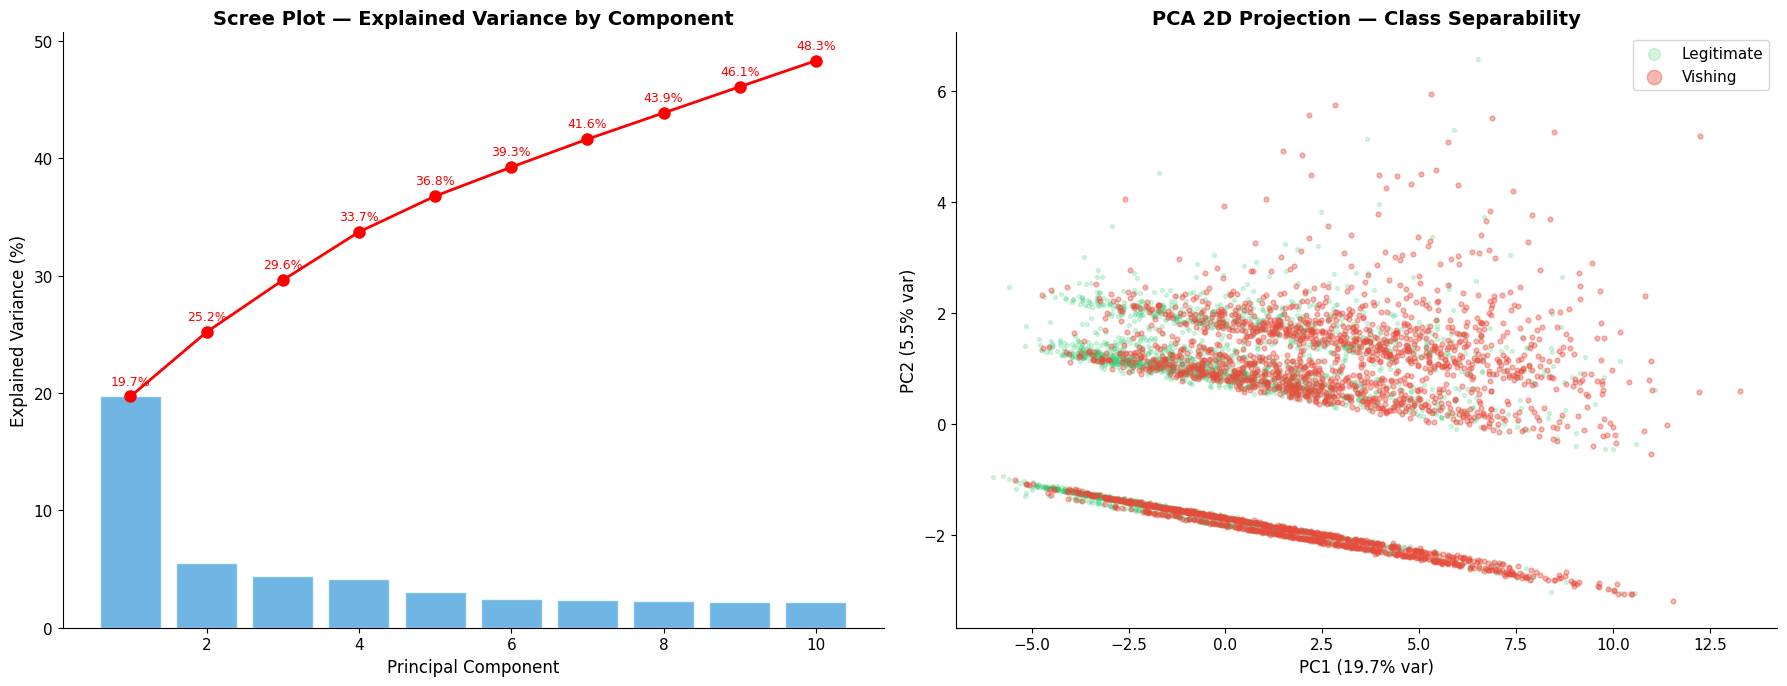


Cumulative variance with 5 components: 36.8%
Cumulative variance with 10 components: 48.3%


In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numeric features (exclude labels and BioCatch scores)
pca_features = [c for c in numeric_cols if c not in exclude + ['hour_of_day']]

X = df[pca_features].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scree plot
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)
axes[0].bar(range(1, 11), explained, color=COLORS['neutral'], edgecolor='white', alpha=0.7)
axes[0].plot(range(1, 11), cumulative, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Explained Variance by Component', fontweight='bold')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    axes[0].text(i+1, c+1, f'{c:.1f}%', ha='center', fontsize=9, color='red')

# 2D projection
idx_legit = df['is_vishing'].values == 0
idx_vishing = df['is_vishing'].values == 1

# Subsample legit for visualization
legit_idx = np.where(idx_legit)[0]
legit_sample_idx = np.random.choice(legit_idx, size=3000, replace=False)

axes[1].scatter(X_pca[legit_sample_idx, 0], X_pca[legit_sample_idx, 1],
               c=COLORS['legit'], alpha=0.2, s=8, label='Legitimate')
axes[1].scatter(X_pca[idx_vishing, 0], X_pca[idx_vishing, 1],
               c=COLORS['vishing'], alpha=0.4, s=12, label='Vishing')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}% var)')
axes[1].set_title('PCA 2D Projection — Class Separability', fontweight='bold')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

print(f'\nCumulative variance with 5 components: {cumulative[4]:.1f}%')
print(f'Cumulative variance with 10 components: {cumulative[9]:.1f}%')

In [42]:
# Top features by loading on PC1 and PC2
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=pca_features)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()

print('TOP 10 FEATURES BY LOADING ON PC1 (main separation component):')
print(loadings.nlargest(10, 'PC1_abs')[['PC1']].to_string())
print(f'\nTOP 10 FEATURES BY LOADING ON PC2:')
print(loadings.nlargest(10, 'PC2_abs')[['PC2']].to_string())

TOP 10 FEATURES BY LOADING ON PC1 (main separation component):
                                 PC1
segmented_typing_ratio      0.266094
data_familiarity_score     -0.235191
hesitation_count            0.231605
dead_time_periods           0.225996
keystroke_variability       0.219927
swipe_directional_variance  0.216477
unusual_screen_visits       0.213325
input_correction_count      0.208913
phone_motion_events         0.204401
amount_field_corrections    0.202908

TOP 10 FEATURES BY LOADING ON PC2:
                              PC2
transaction_attempted    0.599218
time_to_transaction_s    0.599218
transaction_amount_cop   0.366553
is_new_beneficiary       0.361222
phone_call_active       -0.039207
call_overlap_duration_s -0.039207
segmented_typing_ratio  -0.030794
phone_motion_events     -0.029292
hesitation_count        -0.028861
dead_time_periods       -0.028479


## 12. Outlier Detection

In [43]:
# Outlier analysis using IQR
outlier_features = [
    'session_duration_s', 'transaction_amount_cop', 'hesitation_count',
    'total_dead_time_s', 'typing_speed_cps', 'biocatch_risk_score'
]

print('OUTLIER ANALYSIS (IQR method, threshold 1.5×IQR)')
print('='*80)

for feat in outlier_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feat] < lower) | (df[feat] > upper)]
    n_outliers = len(outliers)
    pct_vishing_in_outliers = outliers['is_vishing'].mean() * 100 if n_outliers > 0 else 0
    
    print(f'\n  {feat}:')
    print(f'    IQR: [{Q1:.1f}, {Q3:.1f}], bounds: [{lower:.1f}, {upper:.1f}]')
    print(f'    Outliers: {n_outliers:,} ({n_outliers/len(df)*100:.2f}%)')
    print(f'    % vishing among outliers: {pct_vishing_in_outliers:.1f}% (vs {df["is_vishing"].mean()*100:.1f}% global)')

OUTLIER ANALYSIS (IQR method, threshold 1.5×IQR)

  session_duration_s:
    IQR: [1.0, 1.0], bounds: [1.0, 1.0]
    Outliers: 0 (0.00%)
    % vishing among outliers: 0.0% (vs 5.0% global)

  transaction_amount_cop:
    IQR: [0.0, 675137.5], bounds: [-1012706.2, 1687843.8]
    Outliers: 4,054 (8.11%)
    % vishing among outliers: 9.8% (vs 5.0% global)

  hesitation_count:
    IQR: [3.0, 6.0], bounds: [-1.5, 10.5]
    Outliers: 1,885 (3.77%)
    % vishing among outliers: 14.7% (vs 5.0% global)

  total_dead_time_s:
    IQR: [0.8, 0.8], bounds: [0.8, 0.8]
    Outliers: 369 (0.74%)
    % vishing among outliers: 3.0% (vs 5.0% global)

  typing_speed_cps:
    IQR: [3.9, 5.6], bounds: [1.3, 8.1]
    Outliers: 412 (0.82%)
    % vishing among outliers: 2.4% (vs 5.0% global)

  biocatch_risk_score:
    IQR: [157.0, 402.0], bounds: [-210.5, 769.5]
    Outliers: 267 (0.53%)
    % vishing among outliers: 28.1% (vs 5.0% global)


## 13. Preliminary Feature Importance (quick Random Forest)

We train a quick Random Forest to get a first estimate of the relative importance of features. 
This is not formal modeling — it is exploration.

Random Forest — 5-fold CV AUC: 0.7194 ± 0.0099


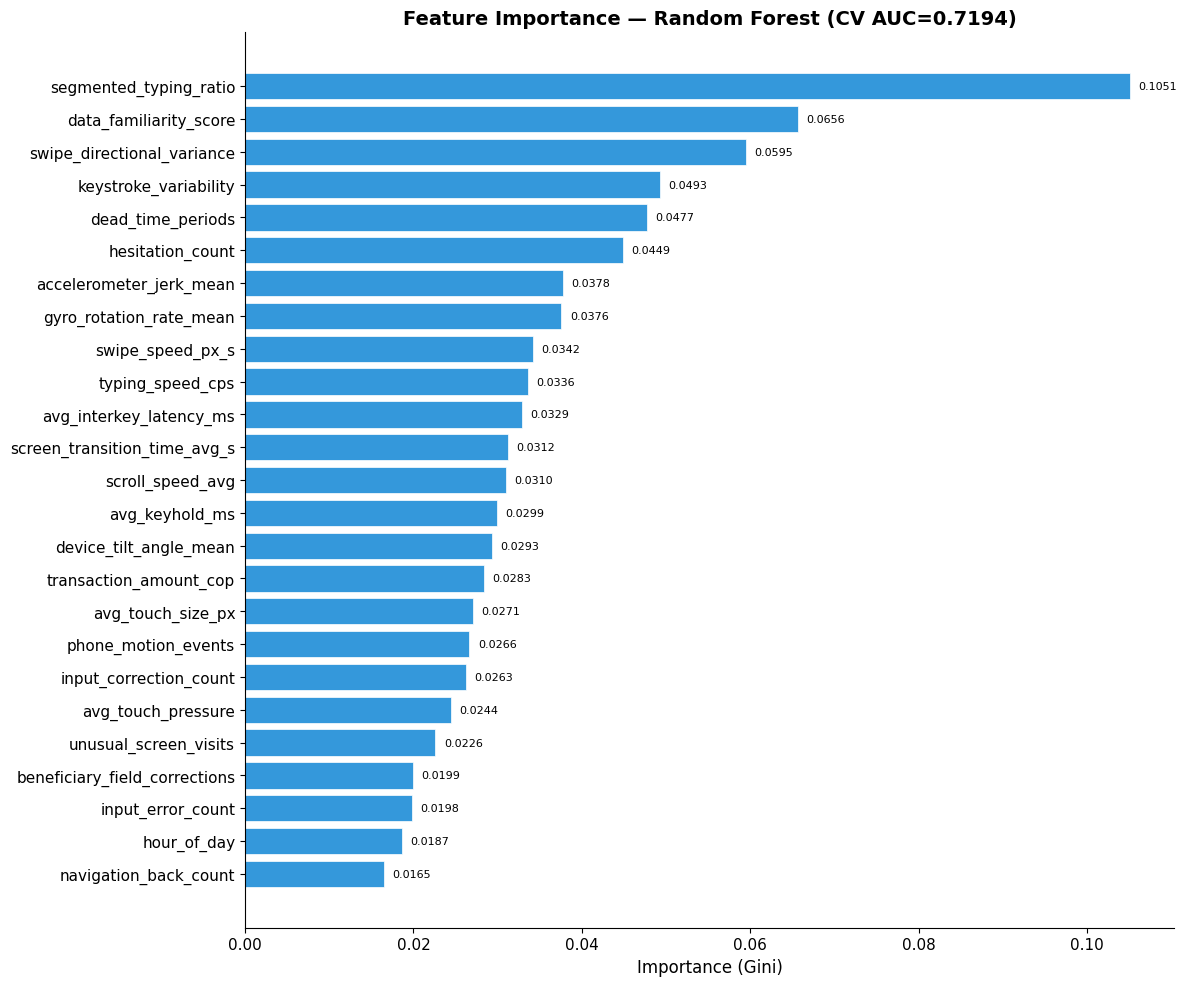

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Prepare features
model_features = [c for c in numeric_cols if c not in exclude]
X_rf = df[model_features].fillna(0).values
y_rf = df['is_vishing'].values

# Quick Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                            class_weight='balanced', n_jobs=-1)
rf.fit(X_rf, y_rf)

# Cross-validation score
cv_scores = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'Random Forest — 5-fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Feature importance
fi = pd.DataFrame({
    'feature': model_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_fi = fi.head(25)
ax.barh(range(len(top_fi)), top_fi['importance'].values, color=COLORS['neutral'],
        edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_fi)))
ax.set_yticklabels(top_fi['feature'].values)
ax.set_xlabel('Importance (Gini)')
ax.set_title(f'Feature Importance — Random Forest (CV AUC={cv_scores.mean():.4f})',
             fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(top_fi['importance'].values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()